---
## This script creates a new Fig. S1, which includes maps of station inhomogeneities
#### 6/30/26
---

In [1]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

In [2]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [3]:
script = os.getcwd() + 'FigS1_resubmissionJun26.ipynb'

In [4]:
# dataframe with the stations we are currently using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [5]:
# read in the temperature breaks dataframe
t_breaks = pd.read_fwf('/home/nsiegert/projects/coastal_sst/data/MergedBreaks_temperatures_hadisd.dat', 
                      names=['STAID', 'a', 'BREAKDATE', 'b', 'break_mo_mean', 'c', 'break_mo_diurnalrange'], 
                      widths=[12, 1, 10, 1, 6, 1, 6])

t_breaks = t_breaks.drop(['a', 'b', 'c'], axis=1)
t_breaks['BREAKDATE'] = pd.to_datetime(t_breaks['BREAKDATE'])
t_breaks

,STAID,BREAKDATE,break_mo_mean,break_mo_diurnalrange
0,010010-99999,1979-03-01,-99.99,0.23
1,010030-99999,2000-03-01,-99.99,-0.82
2,010030-99999,2004-12-01,-1.00,-99.99
3,010030-99999,2009-12-01,-99.99,-0.55
4,010030-99999,2019-09-01,0.57,-99.99
...,...,...,...,...
28050,A00017-04868,2006-10-01,0.39,-99.99
28051,A00017-04868,2013-01-01,0.63,-99.99
28052,A00019-53969,2011-02-01,-0.44,-99.99
28053,A00019-53969,2014-02-01,-99.99,0.39


In [6]:
# read in the dewpoint breaks dataframe
td_breaks = pd.read_fwf('/home/nsiegert/projects/coastal_sst/data/MergedBreaks_dewpoints_hadisd.dat', 
                      names=['STAID', 'a', 'BREAKDATE', 'b', 'break_mo_mean', 'c', 'break_mo_diurnalrange'], 
                      widths=[12, 1, 10, 1, 6, 1, 6])

td_breaks = td_breaks.drop(['a', 'b', 'c'], axis=1)
td_breaks['BREAKDATE'] = pd.to_datetime(td_breaks['BREAKDATE'])
td_breaks

,STAID,BREAKDATE,break_mo_mean,break_mo_diurnalrange
0,010010-99999,1979-03-01,-0.76,-99.99
1,010010-99999,1989-04-01,-1.46,-99.99
2,010010-99999,1994-08-01,1.44,-99.99
3,010010-99999,1998-02-01,-0.81,0.55
4,010010-99999,2000-05-01,-99.99,-0.37
...,...,...,...,...
36196,A00017-04868,2011-02-01,-99.99,0.56
36197,A00017-04868,2014-02-01,0.73,-99.99
36198,A00019-53969,2011-01-01,0.66,-99.99
36199,A00019-53969,2014-12-01,1.65,-1.52


In [7]:
# set maximum inhomogeneity magnitudes of 2, 1, and 0.5˚C, for both monthly mean or diurnal range

In [8]:
# mask out missing breaks
nonmissing_mask_T = t_breaks.break_mo_mean > -99
nonmissing_mask_Td = td_breaks.break_mo_mean > -99

# time mask (inhomogeneity needs to occur between 1990 and 2023
date_mask_T = (t_breaks.BREAKDATE >= pd.to_datetime('1990-01-01')) * (t_breaks.BREAKDATE <= pd.to_datetime('2023-12-31'))
date_mask_Td = (td_breaks.BREAKDATE >= pd.to_datetime('1990-01-01')) * (td_breaks.BREAKDATE <= pd.to_datetime('2023-12-31'))

# for each cutoff
for cutoff in [2, 1, 0.5]:

    # make masks of inhomogeneities based on ˚ cutoff
    inhomog_T_mask = np.abs(t_breaks.break_mo_mean) > cutoff
    inhomog_Td_mask = np.abs(td_breaks.break_mo_mean) > cutoff

    # to ID stations to mask out --> select any stations with non-missing T or Td inhomogeneities that are within the date ranges
    T_mask_out = inhomog_T_mask * nonmissing_mask_T * date_mask_T
    Td_mask_out = inhomog_Td_mask * nonmissing_mask_Td * date_mask_Td

    # gen "bad" staid's from this (doing separately for T and Td b/c they are different lengths)
    T_bad_staids = t_breaks[T_mask_out].STAID.unique()
    Td_bad_staids = td_breaks[Td_mask_out].STAID.unique()

    # pool the lists "bad" STAID's across the 2 variables, take unique
    bad_staids_both = np.unique(T_bad_staids.tolist() + Td_bad_staids.tolist())
    
    # find how many of OUR STAID's should be excluded
    bad_staids_in_our_sample = gdf.STAID.isin(bad_staids_both)
    bad_staids_in_our_sample_T = gdf.STAID.isin(T_bad_staids)
    bad_staids_in_our_sample_Td = gdf.STAID.isin(Td_bad_staids)
    
    gdf['inhomog_{}'.format(cutoff)] = bad_staids_in_our_sample
    gdf['inhomog_{}_T'.format(cutoff)] = bad_staids_in_our_sample_T
    gdf['inhomog_{}_Td'.format(cutoff)] = bad_staids_in_our_sample_Td

    # print
    print('Cutoff: {}˚C, Both: {} T: {} Td: {}'.format(cutoff, np.sum(bad_staids_in_our_sample), np.sum(bad_staids_in_our_sample_T), np.sum(bad_staids_in_our_sample_Td)))

Cutoff: 2˚C, Both: 140 T: 19 Td: 129
Cutoff: 1˚C, Both: 583 T: 181 Td: 513
Cutoff: 0.5˚C, Both: 1089 T: 546 Td: 975


In [9]:
# binned latitude counts of eliminated stations (using inhomogeneity assessment) for supplemental figure
tx_inhomog2_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_2_T'].to_numpy())
tx_inhomog1_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_1_T'].to_numpy())

td_inhomog2_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_2_Td'].to_numpy())
td_inhomog1_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_1_Td'].to_numpy())

# make binned latitude counts of station for supplemental figure
pctreport_binned, bin_midpoints1, bin_nobs1 = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['PCTREPORTING'].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


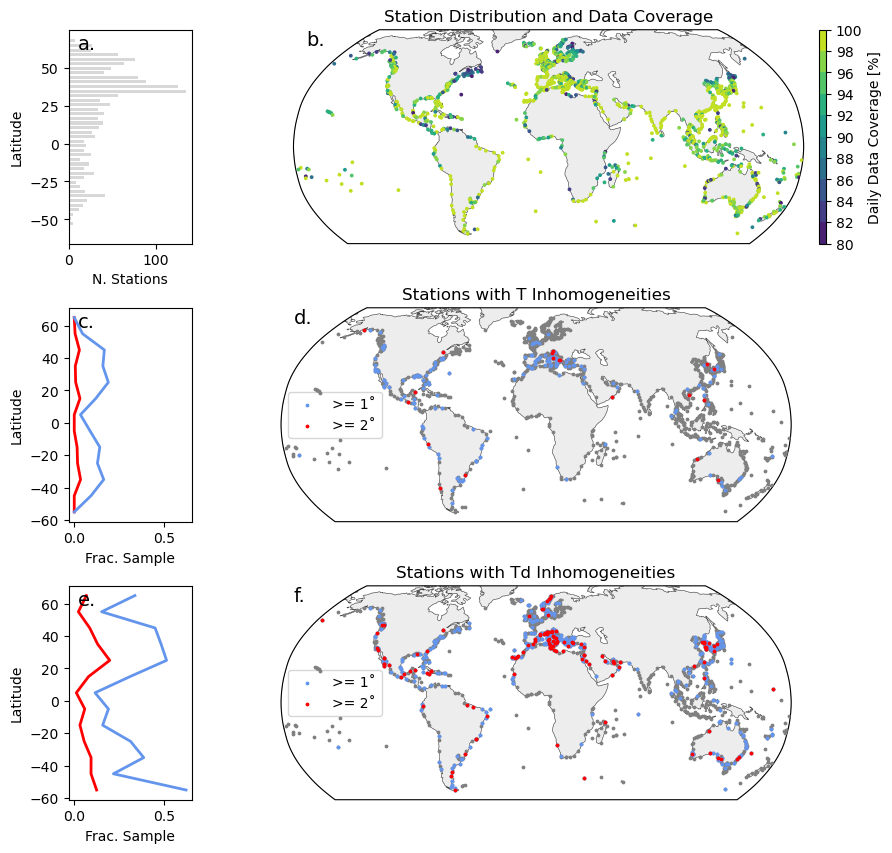

In [10]:
# set cmap for pct reporting
vmin = 80
vmax = 100
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
#cmap.set_over(cols[-1])
#cmap.set_under(bluecolors[-4])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)



# setup axes
nrows = 3
ncols = 2
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 5]) 
gs.update(wspace=0.1, hspace=0.3)



### first row: station number of obs. and percent reporting
## Plot data
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())


# ax 0 - number of obs. by latitude
ax0.barh(bin_midpoints1, bin_nobs1, height=2, color='grey', lw=2, alpha=0.3, zorder=0)
ax0.set(ylabel='Latitude', xlabel='N. Stations')


# ax 1 - pct reporting characteristics
gdf.plot(column='PCTREPORTING', ax=ax1, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
ax1.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.set(title='Station Distribution and Data Coverage')


sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, 
                    ax=ax1, 
                    orientation="vertical",
                    label="Daily Data Coverage [%]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.04, 
                    ticks=bounds,
                    aspect=30)



### rows 2-3: homogeneity test results
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())

ax4 = fig.add_subplot(gs[2,0], sharex=ax2)
ax5 = fig.add_subplot(gs[2,1], projection=ccrs.Robinson())

# ax2 - average fraction of stations eliminated per lat bin
ax2.plot(tx_inhomog2_binned, bin_midpoints, color='r', lw=2, label='>=2˚')
ax2.plot(tx_inhomog1_binned, bin_midpoints, color='cornflowerblue', lw=2, label='>=1˚')
ax2.set(ylabel='Latitude', xlabel='Frac. Sample')
#ax2.legend(loc='lower right')


## ax3 = map of T inhomogeneities
gdf.plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=10, color='grey')
gdf[gdf['inhomog_1_T']].plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='cornflowerblue', label='>= 1˚')
gdf[gdf['inhomog_2_T']].plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='red', label='>= 2˚')
ax3.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.set(title='Stations with T Inhomogeneities')
ax3.legend(loc='center left')

# ax4 - average fraction of (Td) stations eliminated per lat bin
ax4.plot(td_inhomog2_binned, bin_midpoints, color='r', lw=2, label='>= 2˚')
ax4.plot(td_inhomog1_binned, bin_midpoints, color='cornflowerblue', lw=2, label='>= 1˚')
ax4.set(ylabel='Latitude', xlabel='Frac. Sample')

## ax5 = map of T inhomogeneities
gdf.plot(ax=ax5, transform=ccrs.PlateCarree(), markersize=3, zorder=10, color='grey')
gdf[gdf['inhomog_1_Td']].plot(ax=ax5, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='cornflowerblue', label='>= 1˚')
gdf[gdf['inhomog_2_Td']].plot(ax=ax5, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='red', label='>= 2˚')
ax5.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax5.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax5.set(title='Stations with Td Inhomogeneities')
ax5.legend(loc='center left')

# axis texxt labels
ax0.text(s='a.', x=0.075, y=0.91, transform=ax0.transAxes, ha='left', fontsize=14)
ax1.text(s='b.', x=0.025, y=0.925, transform=ax1.transAxes, ha='left', fontsize=14)
ax2.text(s='c.', x=0.075, y=0.91, transform=ax2.transAxes, ha='left', fontsize=14)
ax3.text(s='d.', x=0.025, y=0.925, transform=ax3.transAxes, ha='left', fontsize=14)
ax4.text(s='e.', x=0.075, y=0.91, transform=ax4.transAxes, ha='left', fontsize=14)
ax5.text(s='f.', x=0.025, y=0.925, transform=ax5.transAxes, ha='left', fontsize=14)

plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigS1_coastalsst_grl_6_26.png', format='png', bbox_inches='tight')

plt.show()